In [54]:
import os
from datetime import datetime

caminho_base = r'C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\modelos'
pasta_graficos = os.path.join(caminho_base, 'Gráficos')
pasta_relatorios = os.path.join(caminho_base, 'Relatorios')

for p in [pasta_graficos, pasta_relatorios]:
    if not os.path.exists(p):
        os.makedirs(p)

def obter_caminho_save(prefixo, extensao, pasta):
    timestamp = datetime.now().strftime("%d-%m-%Y_%H-%M")
    return os.path.join(pasta, f"{prefixo}_{timestamp}.{extensao}")

# Carregamento dos Dados e Modelos

In [ ]:
import pandas as pd
import glob
import joblib
import os
from sklearn.model_selection import train_test_split

# Carregamento padrão (Pasta Data)
caminho_dados = os.path.join('..', 'data', '*.csv')
arquivos = glob.glob(caminho_dados)
lista_dfs = []

for f in arquivos:
    if 'dataset_mestre' in f: # Prioridade para o mestre
        df_temp = pd.read_csv(f, sep=';')
        lista_dfs.append(df_temp)

df_proc = pd.concat(lista_dfs, ignore_index=True)

# Engenharia de Atributos Básica (O que os modelos 1, 2 e 3 esperam)
df_proc['mq3_slope'] = df_proc['mq3_raw'].diff().fillna(0)
df_proc['temp_slope'] = df_proc['temperatura'].diff().fillna(0)
df_proc['umid_slope'] = df_proc['umidade_ar'].diff().fillna(0)

# Definição do X e y Padrão (6 colunas)
colunas_basicas = ['mq3_raw', 'temperatura', 'umidade_ar', 'mq3_slope', 'temp_slope', 'umid_slope']
X = df_proc[colunas_basicas]
y = df_proc['validade'].fillna(0)

# Split Padrão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Carregar Modelos Originais
modelo_estado = joblib.load('modelo_1_estado.pkl')
modelo_tempo = joblib.load('modelo_2_tempo_restante.pkl')
encoder_estado = joblib.load('encoder_estado.pkl')

print("✅ Ambiente Padrão Carregado (Modelos 1 e 2 prontos!)")

✅ Ambiente Padrão Carregado (Modelos 1 e 2 prontos!)


# Matriz de Confusão

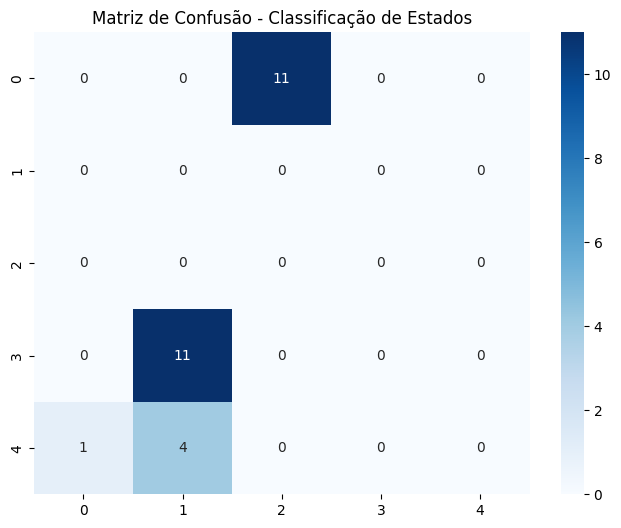

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_estado = modelo_estado.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_estado)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Classificação de Estados')


plt.savefig(obter_caminho_save("matriz_confucao", "png", pasta_graficos), bbox_inches='tight')
plt.show()

# Desafio da Regressão

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


# Criar um modelo básico (Baseline) para comparação
reg_linear = LinearRegression().fit(X_train, y_train)


# Previsões
y_pred_ia = modelo_tempo.predict(X_test)
y_pred_linear = reg_linear.predict(X_test)


print("--- COMPARAÇÃO DE PREVISÃO DE VALIDADE (HORAS) ---")
print(f"Erro Médio da IA (Random Forest): {mean_absolute_error(y_test, y_pred_ia):.2f} horas")
print(f"Erro Médio da Regressão Linear: {mean_absolute_error(y_test, y_pred_linear):.2f} horas")
print(f"R2 Score da IA: {r2_score(y_test, y_pred_ia):.2f}")

--- COMPARAÇÃO DE PREVISÃO DE VALIDADE (HORAS) ---
Erro Médio da IA (Random Forest): 11.49 horas
Erro Médio da Regressão Linear: 9.16 horas
R2 Score da IA: -0.31


# Curva ROC e Limiar de Discriminação

c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


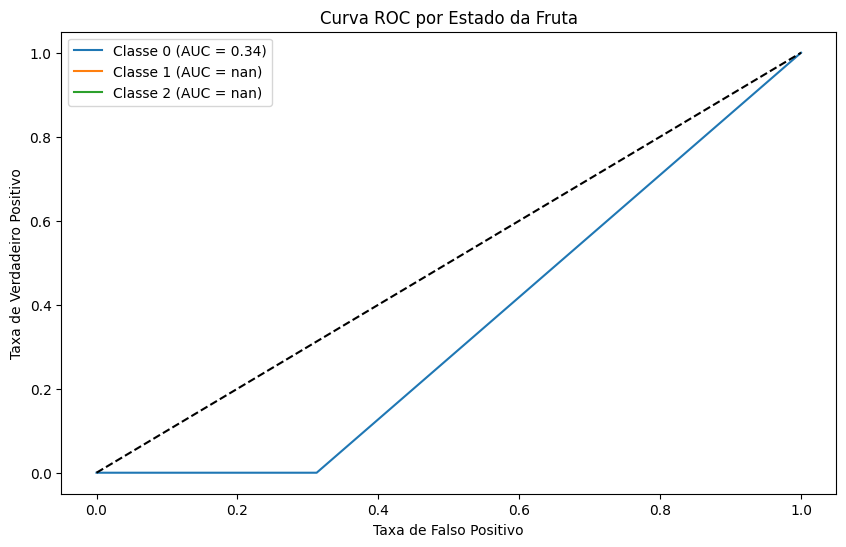

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Binarizar o y_test para curva multiclasse
y_test_bin = label_binarize(y_test, classes=modelo_estado.classes_)
y_score = modelo_estado.predict_proba(X_test)


# Plotar ROC para cada estado
plt.figure(figsize=(10, 6))
for i, classe in enumerate(modelo_estado.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Classe {classe} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC por Estado da Fruta')
plt.legend()
plt.savefig(obter_caminho_save("curva_ROC", "png", pasta_graficos), bbox_inches='tight')
plt.show()

# Feature Importance

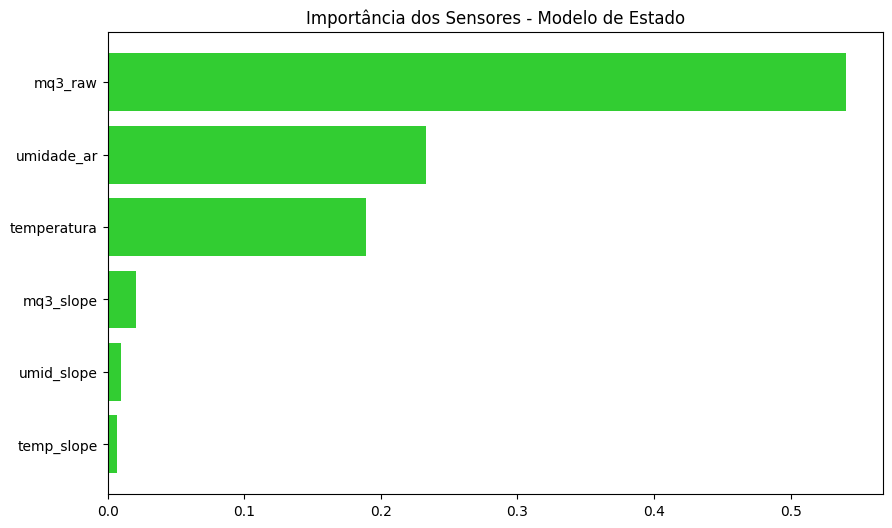

In [38]:
import numpy as np

# Função para extrair importância independente se é Pipeline ou Estimador puro
def extrair_importancia(mod):
    if hasattr(mod, 'steps'): return mod.steps[-1][1].feature_importances_
    if hasattr(mod, 'modelo'): return mod.modelo.feature_importances_ 
    return mod.feature_importances_

importancias = extrair_importancia(modelo_estado)
indices = np.argsort(importancias)

plt.figure(figsize=(10, 6))
plt.title('Importância dos Sensores - Modelo de Estado')
plt.barh(range(len(indices)), importancias[indices], color='limegreen', align='center')
plt.yticks(range(len(indices)), [colunas_modelo[i] for i in indices])


plt.savefig(obter_caminho_save("importancia_sensores", "png", pasta_graficos), bbox_inches='tight')
plt.show()

# Relatório

In [ ]:
import joblib
import pandas as pd
import os
import glob
import datetime
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

# Carregar artefatos
encoder_estado = joblib.load('encoder_estado.pkl')
y_pred_num_estado = modelo_estado.predict(X_test)

y_pred_nomes_estado = encoder_estado.inverse_transform(y_pred_num_estado.astype(int))

y_pred_tempo = modelo_tempo.predict(X_test)
mae_ia = mean_absolute_error(y_test, y_pred_tempo)
r2_ia = r2_score(y_test, y_pred_tempo)

# Configuração de salvamento
agora = datetime.datetime.now()
data_hoje = agora.strftime("%d/%m/%Y %H:%M")

arquivos_existentes = glob.glob(os.path.join(pasta_relatorios, "relatorio_*.md"))
proximo_numero = len(arquivos_existentes) + 1
nome_relatorio = f"relatorio_{proximo_numero}_{agora.strftime('%d-%m-%Y_%H-%M')}.md"
caminho_relatorio = os.path.join(pasta_relatorios, nome_relatorio)

# Montagem do conteúdo 
linhas = [
    f"# Relatório de Validação #{proximo_numero}",
    f"**Data:** {data_hoje}",
    "\n---\n",
    "## 1. Análise de Regressão (Tempo Restante)",
    f"* **Erro Médio (MAE):** {mae_ia:.2f} horas",
    f"* **R2 Score (Precisão):** {r2_ia:.2f}",
    "\n---\n",
    "## 2. Exemplos de Classificação de Estado (IA)",
    "Os estados previstos pela IA para as últimas amostras foram:",
    f"```text\n{y_pred_nomes_estado[:5]}\n```"
]

with open(caminho_relatorio, 'w', encoding='utf-8') as f:
    f.write("\n".join(linhas))

print(f" Relatório #{proximo_numero} salvo com sucesso em: {caminho_relatorio}")

 Relatório #1 salvo com sucesso em: C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\modelos\Relatorios\relatorio_1_01-03-2026_21-49.md


# Stress test - Falha do Sensor MQ3

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import joblib
from sklearn.model_selection import train_test_split

# Carregar o Modelo Novo e ver o que ele precisa
modelo_novo_dict = joblib.load('modelo_frutas_01-03-2026_20-49.pkl')
features_ia_nova = modelo_novo_dict['features']

# Carregar os dados corretamente (usando sep=';')
caminho_dados = os.path.join('..', 'data', 'dataset_mestre_unificado_*.csv')
arquivos = glob.glob(caminho_dados)
if not arquivos:
    arquivos = glob.glob('dataset_mestre_unificado_*.csv')

df_stress_prep = pd.read_csv(arquivos[-1], sep=';') 

# CRIAR AS COLUNAS QUE O MODELO EXIGE
# Extrair dados do timestamp
df_stress_prep['timestamp'] = pd.to_datetime(df_stress_prep['timestamp'])
df_stress_prep['hora'] = df_stress_prep['timestamp'].dt.hour
df_stress_prep['dia_semana'] = df_stress_prep['timestamp'].dt.dayofweek

# Converter tipo de fruta para número (tipofruta_n)
mapeamento_fruta = {'ambiente': 0, 'banana': 1, 'banana_terra': 2, 'tomate': 3}
df_stress_prep['tipofruta_n'] = df_stress_prep['tipofruta'].map(mapeamento_fruta).fillna(0)

# Criar Dummies para o Lote
df_stress_prep = pd.get_dummies(df_stress_prep, columns=['lote'], prefix='lote')

# ALINHAMENTO FINAL DE COLUNAS
X_para_ia_nova = pd.DataFrame(index=df_stress_prep.index)
for col in features_ia_nova:
    if col in df_stress_prep.columns:
        X_para_ia_nova[col] = df_stress_prep[col]
    else:
        X_para_ia_nova[col] = 0 

y_stress = df_stress_prep['validade'].fillna(0)

# Split para o teste
_, X_test_stress_base, _, y_test_stress = train_test_split(
    X_para_ia_nova, y_stress, test_size=0.2, random_state=42
)

print(f" Dados preparados para o Stress Test!")
print(f"Colunas prontas: {list(X_test_stress_base.columns)}")

✅ Dados preparados para o Stress Test!
Colunas prontas: ['temperatura', 'umidade_ar', 'mq3_raw', 'hora', 'dia_semana', 'tipofruta_n', 'lote_lote_Madrugada', 'lote_lote_Madrugada_2', 'lote_lote_Tarde_1', 'lote_lote_[teste_banana_passada]']


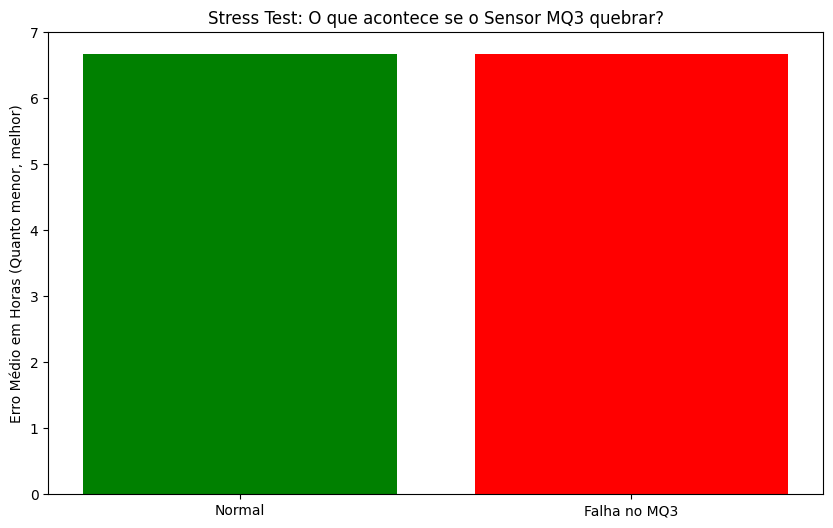

Erro Normal: 6.67h | Erro com Falha: 6.67h


In [ ]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Versão corrompida (Sensor MQ3 falhando)
X_stress_corrompido = X_test_stress_base.copy()
media_mq3 = X_test_stress_base['mq3_raw'].mean()
# Injetando um ruído muito alto (simulando sensor quebrado)
X_stress_corrompido['mq3_raw'] = np.random.normal(media_mq3, 2000, size=len(X_test_stress_base))

# Previsões
ia_final = modelo_novo_dict['modelo']
y_pred_normal = ia_final.predict(X_test_stress_base)
y_pred_stress = ia_final.predict(X_stress_corrompido)

# Cálculo de Erro
mae_normal = mean_absolute_error(y_test_stress, y_pred_normal)
mae_stress = mean_absolute_error(y_test_stress, y_pred_stress)


plt.figure(figsize=(10, 6))
plt.bar(['Normal', 'Falha no MQ3'], [mae_normal, mae_stress], color=['green', 'red'])
plt.title("Stress Test: O que acontece se o Sensor MQ3 quebrar?")
plt.ylabel("Erro Médio em Horas (Quanto menor, melhor)")


plt.savefig(obter_caminho_save("stress_test", "png", pasta_graficos), bbox_inches='tight')
plt.show()

print(f"Erro Normal: {mae_normal:.2f}h | Erro com Falha: {mae_stress:.2f}h")

# Comparação de modelos

Ordem esperada pelo modelo antigo: ['mq3_raw' 'temperatura' 'umidade_ar' 'mq3_slope' 'temp_slope'
 'umid_slope']


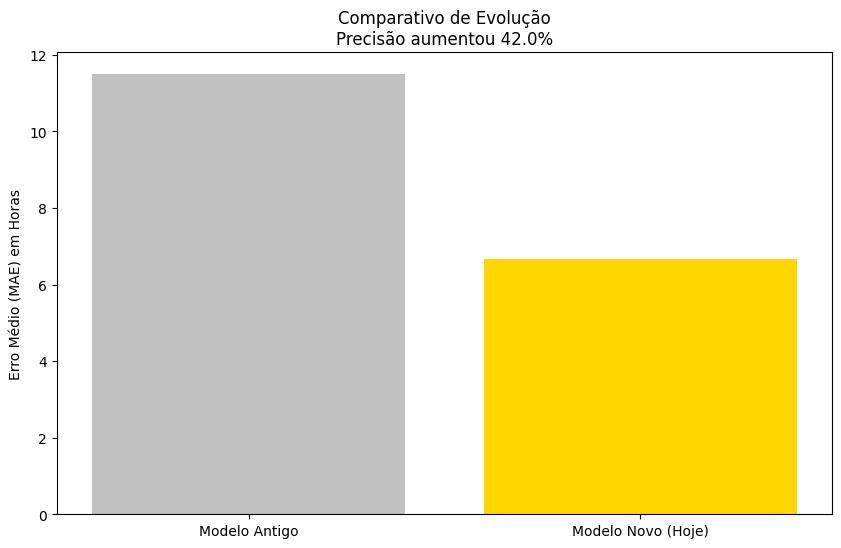

✅ Comparação finalizada!
Erro Antigo: 11.49h | Erro Novo: 6.67h


In [ ]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import joblib


modelo_antigo = joblib.load('modelo_2_tempo_restante.pkl')

# Descobrir a ordem EXATA que o modelo antigo espera
try:
    ordem_correta = modelo_antigo.feature_names_in_
    print(f"Ordem esperada pelo modelo antigo: {ordem_correta}")
except AttributeError:
    ordem_correta = ['mq3_raw', 'temperatura', 'umidade_ar', 'mq3_slope', 'temp_slope', 'umid_slope']

# Preparar os dados garantindo a ordem
X_test_antigo = X_test_stress_base.copy()

# Criar os slopes 
if 'mq3_slope' not in X_test_antigo.columns:
    X_test_antigo['mq3_slope'] = X_test_antigo['mq3_raw'].diff().fillna(0)
    X_test_antigo['temp_slope'] = X_test_antigo['temperatura'].diff().fillna(0)
    X_test_antigo['umid_slope'] = X_test_antigo['umidade_ar'].diff().fillna(0)


X_test_antigo = X_test_antigo[ordem_correta]

# Realizar previsões
y_pred_antigo = modelo_antigo.predict(X_test_antigo)

# Previsões do Modelo Novo 
ia_nova = modelo_novo_dict['modelo']
y_pred_novo = ia_nova.predict(X_test_stress_base)

# Cálculo das métricas e Gráfico
mae_antigo = mean_absolute_error(y_test_stress, y_pred_antigo)
mae_novo = mean_absolute_error(y_test_stress, y_pred_novo)
melhoria = ((mae_antigo - mae_novo) / mae_antigo) * 100

plt.figure(figsize=(10, 6))
plt.bar(['Modelo Antigo', 'Modelo Novo (Hoje)'], [mae_antigo, mae_novo], color=['silver', 'gold'])
plt.title(f"Comparativo de Evolução\nPrecisão aumentou {melhoria:.1f}%")
plt.ylabel("Erro Médio (MAE) em Horas")


plt.savefig(obter_caminho_save("evolucao_modelos", "png", pasta_graficos), bbox_inches='tight')
plt.show()

print(f" Comparação finalizada!")
print(f"Erro Antigo: {mae_antigo:.2f}h | Erro Novo: {mae_novo:.2f}h")

# Análise de Resíduos

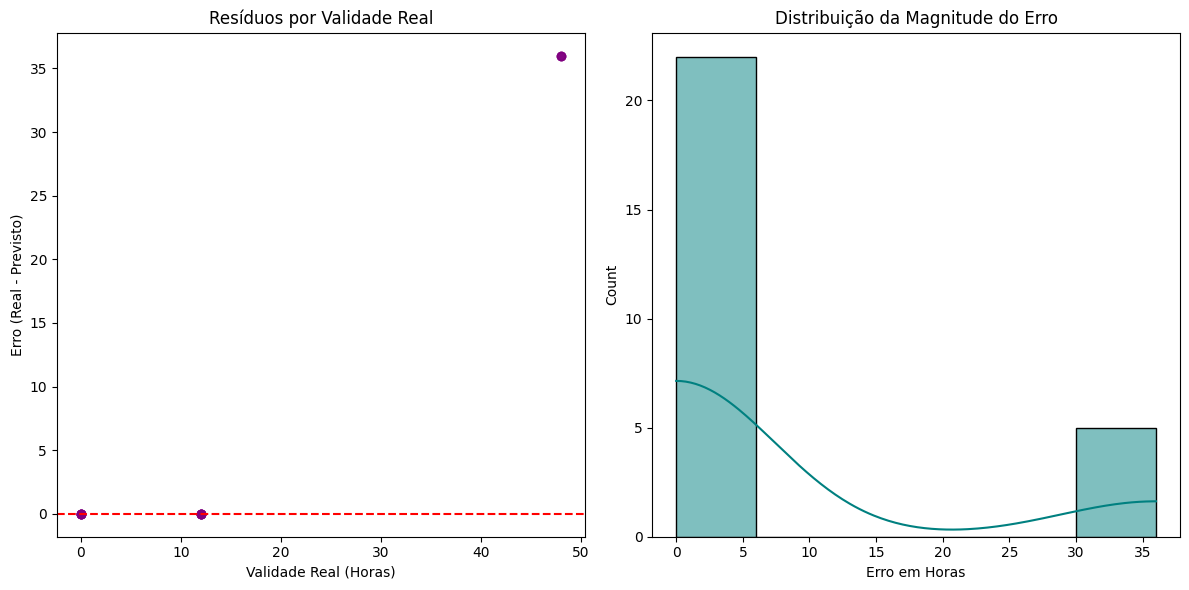

--- DIAGNÓSTICO DE PRECISÃO ---
O maior erro registrado foi de 36.00 horas.
Tendência: A IA está sendo levemente 'Pessimista' (prevendo menos validade do que o real).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular os Resíduos 
ia_nova = modelo_novo_dict['modelo']
y_pred_novo = ia_nova.predict(X_test_stress_base)

residuos = y_test_stress - y_pred_novo

plt.figure(figsize=(12, 6))

# Dispersão Real vs Resíduo
plt.subplot(1, 2, 1)
plt.scatter(y_test_stress, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos por Validade Real')
plt.xlabel('Validade Real (Horas)')
plt.ylabel('Erro (Real - Previsto)')

# Distribuição do Erro (Histograma)
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='teal')
plt.title('Distribuição da Magnitude do Erro')
plt.xlabel('Erro em Horas')

plt.tight_layout()

caminho_residuos = obter_caminho_save("analise_residuos", "png", pasta_graficos)
plt.savefig(caminho_residuos, bbox_inches='tight')
plt.show()

erro_maximo = residuos.abs().max()
print(f"--- DIAGNÓSTICO DE PRECISÃO ---")
print(f"O maior erro registrado foi de {erro_maximo:.2f} horas.")
if residuos.mean() > 0:
    print("Tendência: Prevendo menos validade do que o real.")
else:
    print("Tendência: Prevendo mais validade do que o real.")

# Ranking de Modelos

In [ ]:
import pandas as pd
import joblib
import glob
from sklearn.metrics import mean_absolute_error, r2_score

modelos_arquivos = [
    'modelo_2_tempo_restante.pkl', 
    'modelo_frutas_01-03-2026_20-49.pkl'
]

resultados = []

print("--- INICIANDO BENCHMARK DOS MODELOS ---")

for nome_modelo in modelos_arquivos:
    try:
        mod_data = joblib.load(nome_modelo)
        

        if isinstance(mod_data, dict):
            predictor = mod_data['modelo']
            features = mod_data['features']
            X_input = X_test_stress_base[features] 
        else:
            predictor = mod_data
            features = ['mq3_raw', 'temperatura', 'umidade_ar', 'mq3_slope', 'temp_slope', 'umid_slope']
            X_input = X_test_antigo[features]
            
        previsoes = predictor.predict(X_input)
        mae = mean_absolute_error(y_test_stress, previsoes)
        r2 = r2_score(y_test_stress, previsoes)
        
        resultados.append({
            'Modelo': nome_modelo,
            'Erro Médio (MAE)': f"{mae:.2f} h",
            'Precisão (R2)': f"{r2*100:.1f}%",
            'Complexidade': f"{len(features)} inputs"
        })
        print(f"✅ {nome_modelo} processado.")
        
    except Exception as e:
        print(f" Erro ao testar {nome_modelo}: {e}")

df_ranking = pd.DataFrame(resultados).sort_values(by='Precisão (R2)', ascending=False)

print("\n--- RANKING FINAL DE PERFORMANCE ---")
display(df_ranking)

caminho_csv = obter_caminho_save("ranking_modelos", "csv", pasta_relatorios)
df_ranking.to_csv(caminho_csv, index=False, sep=';')

print(f"\n✅ Tabela de ranking salva em: {caminho_csv}")

--- INICIANDO BENCHMARK DOS MODELOS ---
✅ modelo_2_tempo_restante.pkl processado.
✅ modelo_frutas_01-03-2026_20-49.pkl processado.

--- RANKING FINAL DE PERFORMANCE ---


,Modelo,Erro Médio (MAE),Precisão (R2),Complexidade
1,modelo_frutas_01-03-2026_20-49.pkl,6.67 h,18.8%,10 inputs
0,modelo_2_tempo_restante.pkl,11.49 h,-30.6%,6 inputs



✅ Tabela de ranking salva em: C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\modelos\Relatorios\ranking_modelos_01-03-2026_22-08.csv
